In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
import cv2

Mounted at /content/drive


**Transfer learning models on non augmented data**

In [4]:
# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from tensorflow.keras import Model
from tensorflow.keras.layers.experimental import preprocessing

In [5]:

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [6]:
##import data
train_dir= "/content/drive/MyDrive/NTCC code/train"
val_dir= "/content/drive/MyDrive/NTCC code/val"

In [7]:
class_names = os.listdir(train_dir)
class_names

['SMC', 'MCI', 'CN', 'EMCI', 'LMCI', 'AD']

* 6 class classification needed
features will be extracted from various models pre trained on huge amounts of data and metrics such as f1 score, accuracy will be compared to find gaps to overcome


* data is not augmented and only pre processing done is image size and colour  

**Number of  training images**

In [8]:
for dirpath, dirnames, filenames in os.walk(r"/content/drive/MyDrive/NTCC code/train"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

There are 6 directories and 0 images in /content/drive/MyDrive/NTCC code/train.
There are 0 directories and 337 images in /content/drive/MyDrive/NTCC code/train/SMC.
There are 0 directories and 659 images in /content/drive/MyDrive/NTCC code/train/MCI.
There are 0 directories and 659 images in /content/drive/MyDrive/NTCC code/train/CN.
There are 0 directories and 665 images in /content/drive/MyDrive/NTCC code/train/EMCI.
There are 0 directories and 664 images in /content/drive/MyDrive/NTCC code/train/LMCI.
There are 0 directories and 667 images in /content/drive/MyDrive/NTCC code/train/AD.


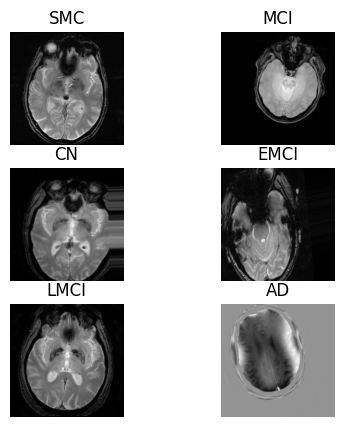

In [11]:
import os # Import the os module to work with file paths

plt.figure(figsize=(5, 5))
for i, class_name in enumerate(class_names):
    # Get a random image from the class directory
    img_name = np.random.choice(os.listdir(os.path.join(train_dir, class_name)))
    img_path = os.path.join(train_dir, class_name, img_name)

    # Read and display the image
    img = cv2.imread(img_path)

    # Check if the image was loaded successfully
    if img is not None:
        plt.subplot(3, 2, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert image from BGR to RGB
        plt.title(class_name)
        plt.axis('off')
    else:
        print(f"Failed to load image: {img_path}") # Print an error message if image loading fails

plt.show()

In [ ]:
#function to pre process images to reshape and black and white

def preprocess_image(image_path, label):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    return image, label

In [12]:
IMG_SHAPE = (224, 224, 3)
BATCH_SIZE = 32

## Start with VGG16

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16

## Loading VGG16 model
base_model = VGG16(weights="imagenet", include_top=False, input_shape= IMG_SHAPE)
base_model.trainable = False

base_model.summary()

58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                              

In [ ]:
vgg_model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(6, activation ="softmax") ## adding our own output layer makes this a form of feature vectors extraction

])
vgg_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 6)                 3078      
                                                                 
Total params: 14717766 (56.14 MB)
Trainable params: 3078 (12.02 KB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


In [ ]:
vgg_model.compile(loss="categorical_crossentropy",
                optimizer = "Adam",
                metrics = ["accuracy"])

In [13]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training Images: ")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size = (224,224),
                                               batch_size = BATCH_SIZE,
                                               class_mode = "categorical")
print("Testing Images: ")
val_data = test_datagen.flow_from_directory(val_dir,
                                             target_size = (224,224),
                                             batch_size = BATCH_SIZE,
                                             class_mode = "categorical")


Training Images: 
Found 3651 images belonging to 6 classes.
Testing Images: 
Found 3000 images belonging to 6 classes.


In [ ]:
# Fit the model using the Datasets
history_vgg = vgg_model.fit(
    train_data,
    epochs=50,
    validation_data=val_data)

Epoch 1/50
115/115 [==============================] - 1323s 12s/step - loss: 1.7480 - accuracy: 0.2558 - val_loss: 1.6962 - val_accuracy: 0.3053
Epoch 2/50
115/115 [==============================] - 126s 1s/step - loss: 1.6177 - accuracy: 0.3306 - val_loss: 1.6214 - val_accuracy: 0.2900
Epoch 3/50
115/115 [==============================] - 129s 1s/step - loss: 1.5550 - accuracy: 0.3451 - val_loss: 1.5623 - val_accuracy: 0.3243
Epoch 4/50
115/115 [==============================] - 129s 1s/step - loss: 1.5073 - accuracy: 0.3785 - val_loss: 1.5372 - val_accuracy: 0.3527
Epoch 5/50
115/115 [==============================] - 129s 1s/step - loss: 1.4809 - accuracy: 0.3818 - val_loss: 1.5254 - val_accuracy: 0.3207
Epoch 6/50
115/115 [==============================] - 128s 1s/step - loss: 1.4533 - accuracy: 0.3895 - val_loss: 1.5088 - val_accuracy: 0.3553
Epoch 7/50
115/115 [==============================] - 130s 1s/step - loss: 1.4301 - accuracy: 0.4136 - val_loss: 1.5053 - val_accuracy: 0.34

## Dense net 121 model


* DenseNet121 function


keras.applications.DenseNet121(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)



* DenseNet169 function


keras.applications.DenseNet169(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)


* DenseNet201 function


keras.applications.DenseNet201(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)







* Optionally loads weights pre-trained on ImageNet. Note that the data format convention used by the model is the one specified in your Keras config at ~/.keras/keras.json.

Note: each Keras Application expects a specific kind of input preprocessing. For DenseNet, call keras.applications.densenet.preprocess_input on your inputs before passing them to the model.

* Arguments

* include_top: whether to include the fully-connected layer at the top of the network.
* weights: one of None (random initialization), "imagenet" (pre-training on I mageNet), or the path to the weights file to be loaded.
* input_tensor: optional Keras tensor (i.e. output of layers.Input()) to use as  image input for the model.
* input_shape: optional shape tuple, only to be specified if include_top is False (otherwise the input shape has to be (224, 224, 3) (with 'channels_last' data format) or (3, 224, 224) (with 'channels_first' data format). It should have exactly 3 inputs channels, and width and height should be no smaller than 32. E.g. (200, 200, 3) would be one valid value.
* pooling: Optional pooling mode for feature extraction when include_top is False.
None means that the output of the model will be the 4D tensor output of the last convolutional block.
avg means that global average pooling will be applied to the output of the last convolutional block, and thus the output of the model will be a 2D tensor.
max means that global max pooling will be applied.
* classes: optional number of classes to classify images into, only to be specified if include_top is True, and if no weights argument is specified.
* classifier_activation: A str or callable. The activation function to use on the "top" layer. Ignored unless include_top=True. Set *classifier_activation=None to return the logits of the "top" layer. When loading pretrained weights, classifier_activation can only be None or "softmax".

In [14]:
from keras.applications import DenseNet121




base_model = DenseNet121(weights="imagenet", include_top=False, input_shape= IMG_SHAPE)
base_model.trainable = False

base_model.summary()


densenet_model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(6, activation ="softmax") ## adding our own output layer makes this a form of feature vectors extraction

])
densenet_model.summary()

29084464/29084464 [==============================] - 0s 0us/step
Model: "densenet121"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormali

In [16]:
densenet_model.compile(loss="categorical_crossentropy",
                optimizer = "Adam",
                metrics = ["accuracy"])

In [1]:
history_densenet = densenet_model.fit(
    train_data,
    epochs=50,
    validation_data=val_data)

NameError: name 'densenet_model' is not defined

In [ ]:
densenet_model.save("/content/drive/MyDrive/NTCC code/transfer learning models")

In [ ]:
## imp classification report code
# code foe classification report with yellowbricks


from sklearn.naive_bayes import GaussianNB
from yellowbrick.classifier import ClassificationReport

# Instantiate the classification model and visualizer
bayes = GaussianNB()
visualizer = ClassificationReport(bayes, classes=classes, support=True)

visualizer.fit(X_train, y_train)  # Fit the visualizer and the model
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()

NameError: name 'classes' is not defined